# 02. 파생변수 검증

센서를 조합한 파생변수 3종이 각 고장 유형과 물리적으로 연결되는지 그래프와 수치로 확인한다.

| 이름 | 계산식 | 물리적 의미 | 연결되는 고장 |
|---|---|---|---|
| tempDiff | processTemp − airTemp [K] | 공정 열이 대기로 빠져나갈 여유 | HDF (열방출) |
| power | torque × rotSpeed × 2π / 60 [W] | 공정에 필요한 기계적 동력 | PWF (전력) |
| wearTorque | toolWear × torque [min·Nm] | 마모된 공구에 걸리는 누적 부하 | OSF (과부하) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")

COLUMNS = {
    "UDI": "udi", "Product ID": "productId", "Type": "productType",
    "Air temperature [K]": "airTemp", "Process temperature [K]": "processTemp",
    "Rotational speed [rpm]": "rotSpeed", "Torque [Nm]": "torque",
    "Tool wear [min]": "toolWear", "Machine failure": "machineFailure",
}
df = pd.read_csv("../../data/ai4i2020.csv", encoding="utf-8-sig").rename(columns=COLUMNS)

SENSORS = ["airTemp", "processTemp", "rotSpeed", "torque", "toolWear"]
FAILURE_TYPES = ["TWF", "HDF", "PWF", "OSF", "RNF"]
TYPE_ORDER = ["L", "M", "H"]

## 1. 파생변수 계산

In [2]:
df["tempDiff"] = df["processTemp"] - df["airTemp"]
df["power"] = df["torque"] * df["rotSpeed"] * 2 * np.pi / 60
df["wearTorque"] = df["toolWear"] * df["torque"]

DERIVED = ["tempDiff", "power", "wearTorque"]
df[DERIVED].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
tempDiff,10000.0,10.0,1.0,7.6,9.3,9.8,11.0,12.1
power,10000.0,6279.7,1067.4,1148.4,5561.2,6271.0,7003.0,10469.9
wearTorque,10000.0,4314.7,2826.6,0.0,1963.6,4013.0,6279.0,16497.0


**계산 검증 (StateBuilder 단위 테스트 기대값으로 재사용)**

첫 행: airTemp 298.1, processTemp 308.6, rotSpeed 1551, torque 42.8, toolWear 0

In [3]:
r = df.iloc[0]
print(f"tempDiff   = {r.tempDiff:.4f}  (기대 10.5)")
print(f"power      = {r.power:.4f}  (기대 42.8 × 1551 × 2π / 60 = {42.8 * 1551 * 2 * np.pi / 60:.4f})")
print(f"wearTorque = {r.wearTorque:.4f}  (기대 0)")

tempDiff   = 10.5000  (기대 10.5)
power      = 6951.5906  (기대 42.8 × 1551 × 2π / 60 = 6951.5906)
wearTorque = 0.0000  (기대 0)


## 2. HDF — tempDiff × rotSpeed

공개 조건: **tempDiff < 8.6 K 이고 rotSpeed < 1380 rpm**.
열을 빼낼 온도차가 작고, 회전이 느려 냉각(공기 흐름)도 약하면 열이 쌓인다.

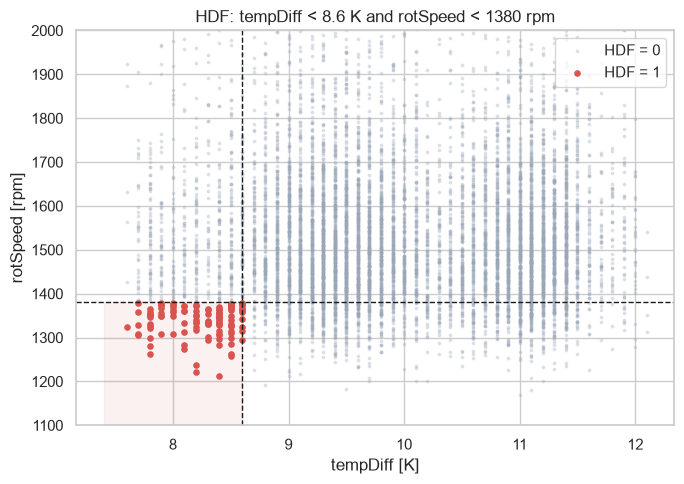

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
normal = df[df["HDF"] == 0]
hdf = df[df["HDF"] == 1]
ax.scatter(normal["tempDiff"], normal["rotSpeed"], s=3, alpha=0.25, color="#9aa7b8", label="HDF = 0")
ax.scatter(hdf["tempDiff"], hdf["rotSpeed"], s=14, color="#d9534f", label="HDF = 1")
ax.axvline(8.6, color="k", ls="--", lw=1)
ax.axhline(1380, color="k", ls="--", lw=1)
ax.fill_between([df["tempDiff"].min() - 0.2, 8.6], 1100, 1380, color="#d9534f", alpha=0.08)
ax.set_xlabel("tempDiff [K]"); ax.set_ylabel("rotSpeed [rpm]")
ax.set_ylim(1100, 2000)
ax.set_title("HDF: tempDiff < 8.6 K and rotSpeed < 1380 rpm")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

In [5]:
in_hdf = (df["tempDiff"] < 8.6) & (df["rotSpeed"] < 1380)
pd.crosstab(in_hdf.rename("조건 영역 안"), df["HDF"].rename("HDF 라벨"), margins=True)

HDF 라벨,0,1,All
조건 영역 안,,,
False,9885,0,9885
True,0,115,115
All,9885,115,10000


## 3. PWF — power

공개 조건: **power < 3500 W 또는 > 9000 W**.
동력이 너무 작으면 공정이 제대로 진행되지 않고, 너무 크면 설비 한계를 넘는다.

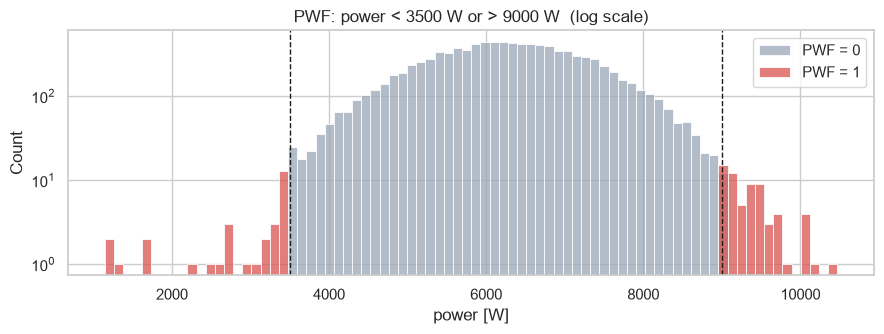

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.5))
bins = np.linspace(df["power"].min(), df["power"].max(), 81)
sns.histplot(df[df["PWF"] == 0], x="power", bins=bins, stat="count", color="#9aa7b8", ax=ax, label="PWF = 0")
sns.histplot(df[df["PWF"] == 1], x="power", bins=bins, stat="count", color="#d9534f", ax=ax, label="PWF = 1")
for x in (3500, 9000):
    ax.axvline(x, color="k", ls="--", lw=1)
ax.set_xlabel("power [W]")
ax.set_yscale("log")
ax.set_title("PWF: power < 3500 W or > 9000 W  (log scale)")
ax.legend()
plt.tight_layout(); plt.show()

In [7]:
in_pwf = (df["power"] < 3500) | (df["power"] > 9000)
pd.crosstab(in_pwf.rename("조건 영역 안"), df["PWF"].rename("PWF 라벨"), margins=True)

PWF 라벨,0,1,All
조건 영역 안,,,
False,9905,0,9905
True,0,95,95
All,9905,95,10000


EDA에서 본 **고장 쪽 torque의 두 봉우리**가 여기서 설명된다:
낮은 torque는 power < 3500 쪽, 높은 torque는 power > 9000 쪽 PWF다.

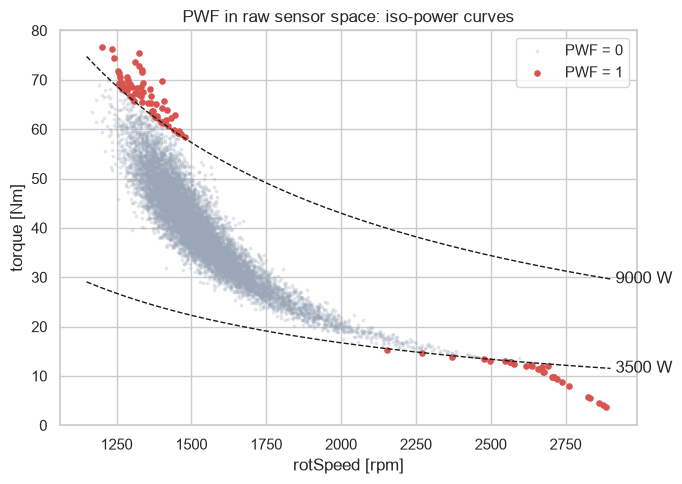

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["rotSpeed"], df["torque"], s=3, alpha=0.2, color="#9aa7b8", label="PWF = 0")
p = df[df["PWF"] == 1]
ax.scatter(p["rotSpeed"], p["torque"], s=14, color="#d9534f", label="PWF = 1")
rpm = np.linspace(1150, 2900, 200)
for w in (3500, 9000):
    ax.plot(rpm, w * 60 / (2 * np.pi * rpm), "k--", lw=1)
    ax.text(rpm[-1], w * 60 / (2 * np.pi * rpm[-1]), f" {w} W", va="center")
ax.set_xlabel("rotSpeed [rpm]"); ax.set_ylabel("torque [Nm]")
ax.set_ylim(0, 80)
ax.set_title("PWF in raw sensor space: iso-power curves")
ax.legend()
plt.tight_layout(); plt.show()

## 4. OSF — wearTorque (제품 타입별)

공개 조건: **wearTorque > 11,000 (L) / 12,000 (M) / 13,000 (H) min·Nm**.
공구가 많이 마모된 상태에서 큰 토크가 걸리면 과부하로 파손된다. 고급 제품(H)일수록 견디는 한계가 높다.

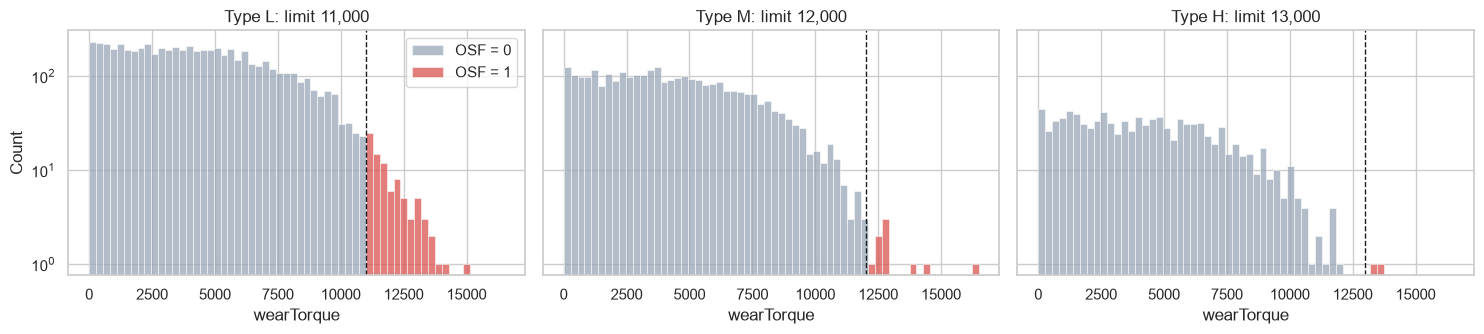

In [9]:
OSF_LIMIT = {"L": 11000, "M": 12000, "H": 13000}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
for ax, t in zip(axes, TYPE_ORDER):
    sub = df[df["productType"] == t]
    bins = np.linspace(0, df["wearTorque"].max(), 61)
    sns.histplot(sub[sub["OSF"] == 0], x="wearTorque", bins=bins, color="#9aa7b8", ax=ax, label="OSF = 0")
    sns.histplot(sub[sub["OSF"] == 1], x="wearTorque", bins=bins, color="#d9534f", ax=ax, label="OSF = 1")
    ax.axvline(OSF_LIMIT[t], color="k", ls="--", lw=1)
    ax.set_yscale("log")
    ax.set_title(f"Type {t}: limit {OSF_LIMIT[t]:,}")
axes[0].legend()
plt.tight_layout(); plt.show()

In [10]:
in_osf = df["wearTorque"] > df["productType"].map(OSF_LIMIT)
pd.crosstab(in_osf.rename("조건 영역 안"), df["OSF"].rename("OSF 라벨"), margins=True)

OSF 라벨,0,1,All
조건 영역 안,,,
False,9902,0,9902
True,0,98,98
All,9902,98,10000


## 5. TWF — toolWear (참고)

TWF는 파생변수가 아니라 toolWear 하나로 정의된다. **200~240분 구간에서 무작위로** 발생한다.

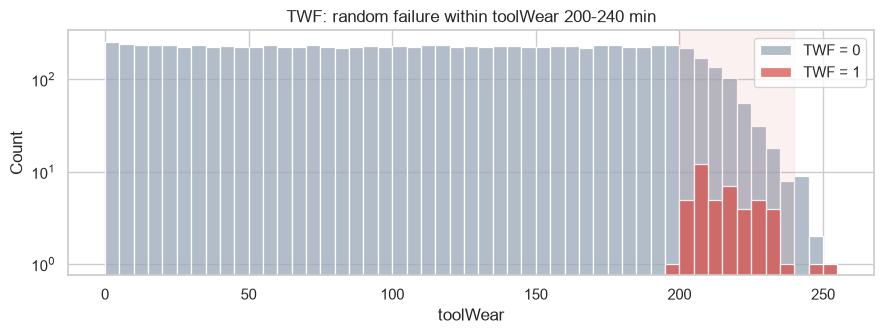

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.5))
bins = np.arange(0, 260, 5)
sns.histplot(df[df["TWF"] == 0], x="toolWear", bins=bins, color="#9aa7b8", ax=ax, label="TWF = 0")
sns.histplot(df[df["TWF"] == 1], x="toolWear", bins=bins, color="#d9534f", ax=ax, label="TWF = 1")
ax.axvspan(200, 240, color="#d9534f", alpha=0.08)
ax.set_yscale("log")
ax.set_title("TWF: random failure within toolWear 200-240 min")
ax.legend()
plt.tight_layout(); plt.show()

In [12]:
in_twf = df["toolWear"].between(200, 240)
pd.crosstab(in_twf.rename("200~240분 구간"), df["TWF"].rename("TWF 라벨"), margins=True)

TWF 라벨,0,1,All
200~240분 구간,,,
False,9207,3,9210
True,747,43,790
All,9954,46,10000


## 6. 원래 센서 vs 파생변수: 분리력 비교

각 고장 유형 라벨에 대해 변수 하나가 주는 정보량(mutual information)을 비교한다.
power처럼 **양쪽 끝에서 고장이 나는** 관계도 잡아내야 하므로 상관계수 대신 MI를 쓴다.

In [13]:
FEATURES = SENSORS + DERIVED
mi = pd.DataFrame(
    {
        ft: mutual_info_classif(df[FEATURES], df[ft], random_state=42, n_neighbors=5)
        for ft in ["HDF", "PWF", "OSF", "TWF"]
    },
    index=FEATURES,
)
mi.round(4)

,HDF,PWF,OSF,TWF
airTemp,0.0183,0.0005,0.0016,0.0000
processTemp,0.0079,0.0005,0.0005,0.0000
rotSpeed,0.0216,0.0210,0.0120,0.0000
torque,0.0130,0.0409,0.0189,0.0000
toolWear,0.0000,0.0000,0.0186,0.0115
tempDiff,0.0290,0.0000,0.0000,0.0002
power,0.0083,0.0534,0.0178,0.0000
wearTorque,0.0018,0.0044,0.0496,0.0039


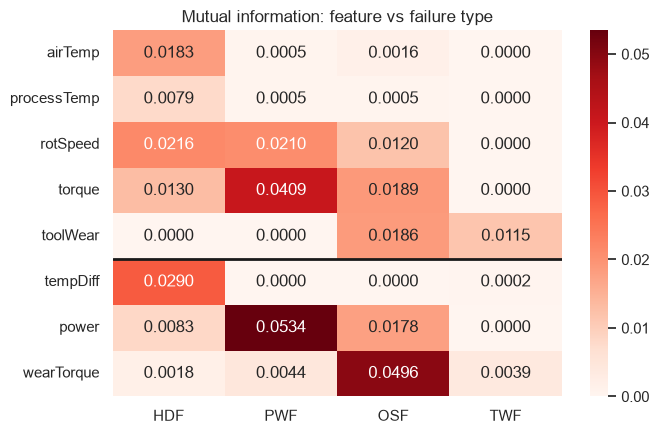

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(mi, annot=True, fmt=".4f", cmap="Reds", ax=ax)
ax.axhline(len(SENSORS), color="k", lw=2)
ax.set_title("Mutual information: feature vs failure type")
plt.tight_layout(); plt.show()

In [15]:
best_raw = mi.loc[SENSORS].max()
best_raw_name = mi.loc[SENSORS].idxmax()
target = {"HDF": "tempDiff", "PWF": "power", "OSF": "wearTorque"}
pd.DataFrame({
    "파생변수": pd.Series(target),
    "파생변수 MI": pd.Series({ft: mi.loc[f, ft] for ft, f in target.items()}),
    "최고 원래 센서": best_raw_name[list(target)],
    "원래 센서 MI": best_raw[list(target)],
}).assign(배율=lambda x: (x["파생변수 MI"] / x["원래 센서 MI"]).round(2)).round(4)

,파생변수,파생변수 MI,최고 원래 센서,원래 센서 MI,배율
HDF,tempDiff,0.0290,rotSpeed,0.0216,1.34
PWF,power,0.0534,torque,0.0409,1.31
OSF,wearTorque,0.0496,torque,0.0189,2.63


## 7. 정리

**파생변수와 고장 유형의 연결 (Phase 1 완료 기준의 근거)**

| 고장 | 조건 | 조건 영역 안 행 | 그중 해당 라벨 | 라벨 전체 중 영역 안 비율 |
|---|---|---|---|---|
| HDF | tempDiff < 8.6 & rotSpeed < 1380 | 115 | 115 | 115 / 115 |
| PWF | power < 3500 or > 9000 | 95 | 95 | 95 / 95 |
| OSF | wearTorque > 11k / 12k / 13k (L/M/H) | 98 | 98 | 98 / 98 |
| TWF | toolWear 200~240 | 790 | 43 | 43 / 46 |

- HDF, PWF, OSF는 파생변수로 만든 조건과 라벨이 **한 건도 어긋나지 않는다.**
  데이터가 이 수식으로 생성된 합성 데이터이기 때문이다 → 룰 엔진이 유형 라벨 기준으로는 완벽하게 나오는 것이 정상이며, 이를 README 한계점에 명시한다.
- 원래 센서 공간에서 PWF는 등동력 곡선(torque = P·60 / 2π·rpm)이라는 곡선 경계를 가진다.
  power 하나로 바꾸면 **직선 임계값 두 개**로 단순해진다. EDA에서 본 고장 쪽 torque의 두 봉우리도 이것으로 설명된다.
- 정보량(MI) 기준으로 파생변수가 가장 좋은 원래 센서보다 HDF 1.34배, PWF 1.31배, OSF 2.63배 높다.
- TWF는 200~240분 구간 790행 중 43행(5.4%)만 고장이다. 구간 밖에서도 3건(198, 246, 253분)이 있다.
  구간 안에서 무작위로 발생하므로 **룰로는 정밀도를 높일 수 없다** → ML 또는 "경고" 수준 판정이 필요한 영역.

**1-6(룰 엔진)으로 넘길 것**
- 유형 라벨 기준이 아니라 `machineFailure` 기준으로 평가하면, RNF와 유형 라벨 없는 고장 9건 때문에 재현율이 100%가 되지 않는다.
- 정답 기준(`machineFailure` vs 유형 라벨)과 TWF 처리 방식을 정해야 한다.